# Box Office Bomb Data Pipeline Assignment

**Total Marks: 20**

This notebook implements an end-to-end pipeline to:
1. Scrape box office bomb data from Wikipedia
2. Validate & clean data using Pydantic
3. Enrich with OMDb API data
4. Perform consistency checks
5. Create final categorized dataset

## Setup and Imports

In [ ]:
# Import required libraries
import pandas as pd
import requests
from bs4 import BeautifulSoup
from pydantic import BaseModel, field_validator, ValidationError
from typing import Optional
import re
import time
from pathlib import Path

## Task 1: Scrape the "Bombs" Table (4 Marks)

Extract raw data from the Wikipedia HTML file:
- Film Title (with symbols like § and †)
- Year
- Net production budget (may contain ranges like "$100–160")
- Estimated loss (Nominal column)

Note:
- You need to extract the entire raw string with the symbols, references, etc along with the titles.
- You must handle the nested headers in the Wikipedia table (Budget and Loss columns have sub-headers).

In [ ]:
def scrape_box_office_bombs():
    """
    Scrape the box office bombs table from the local HTML file.
    Returns a list of dictionaries with raw extracted data.
    """
    # TODO: Load the HTML file
    URL = "https://en.wikipedia.org/wiki/List_of_biggest_box-office_bombs"
    headers = {
      "User-Agent": "Chrome/120.0"
    }

    response = requests.get(URL, headers = headers)
    response.raise_for_status()

    # TODO: Parse with BeautifulSoup
    soup = BeautifulSoup(response.text, 'html.parser')

    # TODO: Find the main table - it's wikitable sortable with caption "Biggest box-office bombs"
    tables = soup.find_all("table", class_="wikitable")
    table = None

    for t in tables:
        if "sortable" not in t.get("class", []):
            continue

        caption = t.find("caption")
        if caption and caption.get_text(strip=True) == "Biggest box-office bombs":
            table = t
            break

    if table is None:
        raise ValueError("Table not found")

    raw_data = []

    # TODO: Iterate through rows (skip headers) and extract: 'raw_title', 'raw_year', 'raw_budget', 'raw_loss'.
    # Store extracted data in raw_data. Example entry: {'raw_title': 'Town & Country', 'raw_year': '2001', 'raw_budget': '$90', 'raw_loss': '$10.4'}
    rows = table.find("tbody").find_all("tr")
    for row in rows[1:]:  # skip header rows
        cells = row.find_all("td")

        # Defensive check (some rows may be malformed)
        if len(cells) < 6:
            continue

        raw_data.append({
            "raw_title": row.find("th").get_text(strip=True),
            "raw_year": cells[0].get_text(strip=True),
            "raw_budget": cells[1].get_text(strip=True),
            "raw_loss": cells[2].get_text(strip=True)
        })
    return raw_data

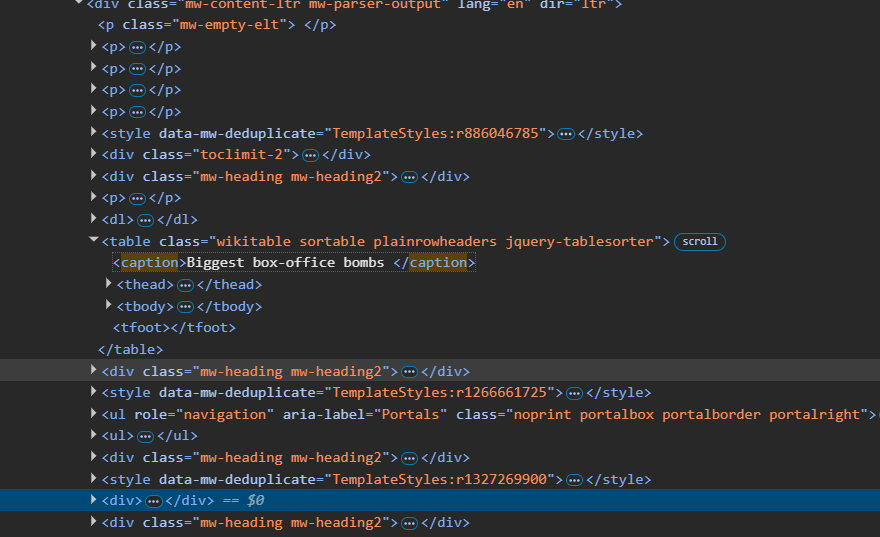

In [ ]:
# Test the scraping function
raw_movies = scrape_box_office_bombs()
print(f"Scraped {len(raw_movies)} movies")
print("\nLast 15 raw entries:")
for i, movie in enumerate(raw_movies[-15:]):
    print(f"\n{i+1}. {movie}")

Scraped 139 movies

Last 15 raw entries:

1. {'raw_title': 'Town & Country', 'raw_year': '2001', 'raw_budget': '$90', 'raw_loss': '$10.4'}

2. {'raw_title': 'Transformers: The Last Knight', 'raw_year': '2017', 'raw_budget': '$217–260', 'raw_loss': '$605.4'}

3. {'raw_title': 'Treasure Planet', 'raw_year': '2002', 'raw_budget': '$140', 'raw_loss': '$109.6'}

4. {'raw_title': 'Tron: Ares†', 'raw_year': '2025', 'raw_budget': '$220', 'raw_loss': '$142.2'}

5. {'raw_title': 'Turning Red§', 'raw_year': '2022', 'raw_budget': '$175', 'raw_loss': '$19.8'}

6. {'raw_title': 'Valerian and the City of a Thousand Planets', 'raw_year': '2017', 'raw_budget': '$177.2–180', 'raw_loss': '$225.9'}

7. {'raw_title': 'West Side Story', 'raw_year': '2021', 'raw_budget': '$100', 'raw_loss': '$76'}

8. {'raw_title': 'Wild Wild West', 'raw_year': '1999', 'raw_budget': '$170', 'raw_loss': '$217.7'}

9. {'raw_title': 'Windtalkers', 'raw_year': '2002', 'raw_budget': '$115–120', 'raw_loss': '$77.6'}

10. {'raw_tit

## Task 2: Pydantic Data Parsing & Validation (6 Marks)

Create a Pydantic model that:
- Cleans titles (removes §, †, and footnotes like [nb 2], [1])
- Parses numeric values (handles ranges, currency symbols)
- Validates year as integer

In [ ]:
class MovieData(BaseModel):
    """
    Pydantic model for validating and cleaning movie data.
    """
    # TODO: Define the 4 required fields with their types:
    # title (str), year (int), budget_millions (float), loss_millions (float)
    title: str
    year: int
    budget_millions: float
    loss_millions: float

    @field_validator('title', mode='before')
    @classmethod
    def clean_title(cls, v):
        if not isinstance(v, str):
            raise ValueError("Title must be a string")
        v = v.replace("§", "").replace("†", "")
        v = re.sub(r"\[.*?\]", "", v)
        return v.strip()

    @field_validator('year', mode='before')
    @classmethod
    def validate_year(cls, v):
        if not isinstance(v, str):
            raise ValueError("Year must be a string")
        digits = re.sub(r"\D", "", v)
        if not digits:
            raise ValueError("Invalid year")
        return int(digits)

    @field_validator('budget_millions', mode='before')
    @classmethod
    def parse_budget(cls, v):
        return cls._parse_numeric_value(v)

    @field_validator('loss_millions', mode='before')
    @classmethod
    def parse_loss(cls, v):
        return cls._parse_numeric_value(v)

    @staticmethod
    def _parse_numeric_value(v):
        if not isinstance(v, str):
            raise ValueError("Numeric value must be a string")
        v = v.replace("$", "")
        v = re.sub(r"\[.*?\]", "", v)
        v = v.replace("–", "-").replace("—", "-")
        v = v.strip()

        if "-" in v:
            parts = v.split("-")
            if len(parts) != 2:
                raise ValueError("Invalid range format")

            low = float(parts[0].strip())
            high = float(parts[1].strip())

            return (low + high) / 2

        # Single numeric value
        return float(v)

In [ ]:
# Validate and clean the raw data
validated_movies = []
failed_validations = []

for raw_movie in raw_movies:
    try:
        movie = MovieData(
            title=raw_movie['raw_title'],
            year=raw_movie['raw_year'],
            budget_millions=raw_movie['raw_budget'],
            loss_millions=raw_movie['raw_loss']
        )
        validated_movies.append(movie)
    except ValidationError as e:
        failed_validations.append({
            'raw_data': raw_movie,
            'error': str(e)
        })
        print(f"Validation failed for {raw_movie['raw_title']}: {e}")

print(f"\n{'='*60}")
print(f"Validation Results:")
print(f"Successfully validated: {len(validated_movies)} movies")
print(f"Failed validations: {len(failed_validations)} movies")
print(f"{'='*60}")

# Show first 3 validated movies
print("\nLast 15 validated movies:")
for i, movie in enumerate(validated_movies[-15:]):
    print(f"\n{i+1}. {movie.model_dump()}")


Validation Results:
Successfully validated: 139 movies
Failed validations: 0 movies

Last 15 validated movies:

1. {'title': 'Town & Country', 'year': 2001, 'budget_millions': 90.0, 'loss_millions': 10.4}

2. {'title': 'Transformers: The Last Knight', 'year': 2017, 'budget_millions': 238.5, 'loss_millions': 605.4}

3. {'title': 'Treasure Planet', 'year': 2002, 'budget_millions': 140.0, 'loss_millions': 109.6}

4. {'title': 'Tron: Ares', 'year': 2025, 'budget_millions': 220.0, 'loss_millions': 142.2}

5. {'title': 'Turning Red', 'year': 2022, 'budget_millions': 175.0, 'loss_millions': 19.8}

6. {'title': 'Valerian and the City of a Thousand Planets', 'year': 2017, 'budget_millions': 178.6, 'loss_millions': 225.9}

7. {'title': 'West Side Story', 'year': 2021, 'budget_millions': 100.0, 'loss_millions': 76.0}

8. {'title': 'Wild Wild West', 'year': 1999, 'budget_millions': 170.0, 'loss_millions': 217.7}

9. {'title': 'Windtalkers', 'year': 2002, 'budget_millions': 117.5, 'loss_millions':

## Task 3: Enrich with OMDb Data (4 Marks)

Query OMDb API for each movie to get:
- Plot
- Metascore
- IMDb Rating
- Director
- Language

Handle API failures (Response='False') or missing fields ('N/A') gracefully by storing them as None. Do not delete the row.

In [ ]:
# OMDb API configuration
OMDB_API_KEY = "a6a8c3a6"
OMDB_BASE_URL = "http://www.omdbapi.com/"

def query_omdb(title: str, year: int) -> dict:

    # TODO: Construct params and make GET request
    params = {
        "apikey": OMDB_API_KEY,
        "t": title,
        "y": year,
        "plot": "short"
    }

    try:
        response = requests.get(OMDB_BASE_URL, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
    except Exception:
        # Network / JSON / timeout error
        return {
            "plot": None,
            "metascore": None,
            "imdb_rating": None,
            "director": None,
            "language": None,
            "omdb_year": None
        }
    # TODO: Handle 'Response': 'False'
    if data.get("Response") == "False":
        return {
            "plot": None,
            "metascore": None,
            "imdb_rating": None,
            "director": None,
            "language": None,
            "omdb_year": None
        }

    # TODO: Extract fields and handle 'N/A' conversion to None/Numbers
    def clean_value(v):
        if v == "N/A":
            return None
        return v

    plot = clean_value(data.get("Plot"))
    director = clean_value(data.get("Director"))
    language = clean_value(data.get("Language"))

    metascore_raw = clean_value(data.get("Metascore"))
    if metascore_raw is not None:
      metascore_rating = float(metascore_raw)
    else:
      metascore_rating = None

    imdb_raw = clean_value(data.get("imdbRating"))
    if imdb_raw is not None:
      imdb_rating = float(imdb_raw)
    else:
      imdb_rating = None

    omdb_year_raw = data.get("Year")

    if omdb_year_raw and omdb_year_raw != "N/A":
        omdb_year = int(omdb_year_raw[:4])
    else:
        omdb_year = None

    return  {
        "plot": plot,
        "metascore": metascore_rating,
        "imdb_rating": imdb_rating,
        "director": director,
        "language": language,
        "omdb_year": omdb_year
    }


In [ ]:
# Enrich each validated movie with OMDb data
enriched_data = []
print("Querying OMDb API...")

# TODO: Loop through validated_movies, call query_omdb, and merge data
for movie in validated_movies:
  omdb_data = query_omdb(movie.title, movie.year)
  enriched_movie = {
        "title": movie.title,
        "year": movie.year,
        "budget_millions": movie.budget_millions,
        "loss_millions": movie.loss_millions,
        "plot": omdb_data["plot"],
        "metascore": omdb_data["metascore"],
        "imdb_rating": omdb_data["imdb_rating"],
        "director": omdb_data["director"],
        "language": omdb_data["language"],
        "omdb_year": omdb_data["omdb_year"]
    }

  enriched_data.append(enriched_movie)

print(f"\nEnriched {len(enriched_data)} movies with OMDb data")

# Show sample enriched data
print("\nFirst enriched entry:")
print(enriched_data[0])

import json
print(json.dumps(enriched_data[0], indent=4))

Querying OMDb API...

Enriched 139 movies with OMDb data

First enriched entry:
{'title': 'The 13th Warrior', 'year': 1999, 'budget_millions': 130.0, 'loss_millions': 61.7, 'plot': 'A man, having fallen in love with the wrong woman, is sent by the sultan himself on a diplomatic mission to a distant land as an ambassador. Stopping at a Viking village port to restock on supplies, he finds himself unwittingly em...', 'metascore': 42.0, 'imdb_rating': 6.6, 'director': 'John McTiernan', 'language': 'English, Latin, Swedish, Norse, Old, Danish, Arabic', 'omdb_year': 1999}
{
    "title": "The 13th Warrior",
    "year": 1999,
    "budget_millions": 130.0,
    "loss_millions": 61.7,
    "plot": "A man, having fallen in love with the wrong woman, is sent by the sultan himself on a diplomatic mission to a distant land as an ambassador. Stopping at a Viking village port to restock on supplies, he finds himself unwittingly em...",
    "metascore": 42.0,
    "imdb_rating": 6.6,
    "director": "John

## Task 4: Data Consistency Check (2 Marks)

Compare Wikipedia year with OMDb year:
- "Verified": Years match (±1 year tolerance)
- "Mismatch": Years differ by >1
- "Not Found": OMDb returned no data

In [ ]:
def determine_match_status(wiki_year: int, omdb_year: Optional[int]) -> str:
    if omdb_year is None:
        return "Not Found"
    if abs(wiki_year - omdb_year) <= 1:
        return "Verified"
    return "Mismatch"

# TODO: Apply this function to your enriched_data list and add match_status to each entry
for movie in enriched_data:
    movie["match_status"] = determine_match_status(
        wiki_year=movie["year"],
        omdb_year=movie.get("omdb_year")
    )

# Show match status distribution
df_temp = pd.DataFrame(enriched_data)
print("Match Status Distribution:")
print(df_temp['match_status'].value_counts())

# Show some mismatches if any
mismatches = df_temp[df_temp['match_status'] == 'Mismatch']
if len(mismatches) > 0:
    print(f"\nSample Mismatches (showing up to 5):")
    print(mismatches[['title', 'year', 'omdb_year', 'match_status']].head())

Match Status Distribution:
match_status
Verified     137
Not Found      2
Name: count, dtype: int64


## Task 5: Final Dataset & Categorization (4 Marks)

Create final DataFrame with:
- Loss_Category based on estimated loss:
  - "Catastrophic": Loss ≥ \$100M

  - "Severe": Loss between \$50M and \$100M

  - "Moderate": Loss < \$50M
- Save to `box_office_failures.csv`

Required columns: Title, Year, Director, Language, Budget_Millions, Loss_Millions, Loss_Category, IMDb_Rating, Metascore, Match_Status

In [ ]:
def categorize_loss(loss_millions: float) -> str:
    if loss_millions >= 100:
        return "Catastrophic"
    elif 50 <= loss_millions < 100:
        return "Severe"
    else:
        return "Moderate"

# TODO: Create DataFrame from enriched_data
df = pd.DataFrame(enriched_data)

# TODO: Add Loss_Category
df["Loss_Category"] = df["loss_millions"].apply(categorize_loss)

# TODO: Select and rename columns to match requirements
df_final = df.rename(columns={
    "title": "Title",
    "year": "Year",
    "director": "Director",
    "language": "Language",
    "budget_millions": "Budget_Millions",
    "loss_millions": "Loss_Millions",
    "imdb_rating": "IMDb_Rating",
    "metascore": "Metascore",
    "match_status": "Match_Status"
})

df_final = df_final[
    [
        "Title",
        "Year",
        "Director",
        "Language",
        "Budget_Millions",
        "Loss_Millions",
        "Loss_Category",
        "IMDb_Rating",
        "Metascore",
        "Match_Status",
    ]
]

# Display summary statistics
print("Final Dataset Summary:")
print(f"Total movies: {len(df_final)}")
print(f"\nLoss Category Distribution:")
print(df_final['Loss_Category'].value_counts())
print(f"\nBasic Statistics:")
print(df_final[['Budget_Millions', 'Loss_Millions', 'IMDb_Rating', 'Metascore']].describe())

# Display first few rows
print(f"\nFirst 10 rows of final dataset:")
df_final.head(10)

Final Dataset Summary:
Total movies: 139

Loss Category Distribution:
Loss_Category
Catastrophic    63
Moderate        52
Severe          24
Name: count, dtype: int64

Basic Statistics:
       Budget_Millions  Loss_Millions  IMDb_Rating   Metascore
count       139.000000     139.000000   137.000000  134.000000
mean        129.552518     115.758993     5.816058   46.529851
std          58.126686     108.118768     1.098276   15.359693
min          17.000000       1.100000     2.100000    9.000000
25%          81.250000      26.600000     5.400000   37.000000
50%         117.500000      80.800000     6.000000   46.000000
75%         175.000000     173.850000     6.600000   56.750000
max         326.000000     605.400000     8.000000   85.000000

First 10 rows of final dataset:


,Title,Year,Director,Language,Budget_Millions,Loss_Millions,Loss_Category,IMDb_Rating,Metascore,Match_Status
0,The 13th Warrior,1999,John McTiernan,"English, Latin, Swedish, Norse, Old, Danish, A...",130.0,61.7,Severe,6.6,42.0,Verified
1,The 355,2022,Simon Kinberg,"English, Chinese, Spanish, French, German, Ara...",57.5,27.7,Moderate,5.6,40.0,Verified
2,47 Ronin,2013,Carl Rinsch,"English, Japanese",200.0,151.8,Catastrophic,6.2,28.0,Verified
3,The Adventures of Baron Munchausen,1988,Terry Gilliam,English,46.6,8.1,Moderate,7.1,69.0,Verified
4,The Adventures of Pluto Nash,2002,Ron Underwood,English,100.0,7.1,Moderate,3.9,12.0,Verified
5,The Adventures of Rocky & Bullwinkle,2000,Des McAnuff,English,87.3,35.1,Moderate,4.3,36.0,Verified
6,The Alamo,2004,John Lee Hancock,"English, Spanish",107.0,25.8,Moderate,6.1,47.0,Verified
7,Alexander,2004,Oliver Stone,English,155.0,167.3,Catastrophic,5.6,40.0,Verified
8,Ali,2001,Michael Mann,"English, French, Swahili",107.0,87.7,Severe,6.7,65.0,Verified
9,Allied,2016,Robert Zemeckis,"English, French, German, Arabic",85.0,118.6,Catastrophic,7.1,60.0,Verified


In [ ]:
# Save to CSV
output_path = 'box_office_failures.csv'

# TODO: Save DataFrame to CSV
df_final.to_csv(output_path, index=False)
print(f"✓ Dataset saved to: {output_path}")
print(f"✓ Total records: {len(df_final)}")

✓ Dataset saved to: box_office_failures.csv
✓ Total records: 139


## Additional Analysis (Optional)

In [ ]:
# Show some interesting insights
print("Top 10 Biggest Box Office Bombs (by loss):")
print(df_final.nlargest(10, 'Loss_Millions')[['Title', 'Year', 'Director', 'Loss_Millions', 'Loss_Category']])

print("\n" + "="*60)
print("\nMovies with Lowest IMDb Ratings:")
lowest_rated = df_final[df_final['IMDb_Rating'].notna()].nsmallest(5, 'IMDb_Rating')
print(lowest_rated[['Title', 'Year', 'Director', 'IMDb_Rating', 'Metascore', 'Loss_Millions']])

print("\n" + "="*60)
print("\nAverage Loss by Category:")
print(df_final.groupby('Loss_Category')['Loss_Millions'].agg(['mean', 'count']))

print("\n" + "="*60)
print("\nTop 5 Most Common Directors in Box Office Bombs:")
print(df_final['Director'].value_counts().head())

Top 10 Biggest Box Office Bombs (by loss):
                                     Title  Year            Director  \
125          Transformers: The Last Knight  2017         Michael Bay   
88                               The Mummy  2017       Alex Kurtzman   
108                Solo: A Star Wars Story  2018          Ron Howard   
19                              Black Adam  2022  Jaume Collet-Serra   
61   Indiana Jones and the Dial of Destiny  2023       James Mangold   
119                                  Tenet  2020   Christopher Nolan   
49                       The Good Dinosaur  2015          Peter Sohn   
26                       A Christmas Carol  2009     Robert Zemeckis   
100                  Rise of the Guardians  2012        Peter Ramsey   
15                              Battleship  2012          Peter Berg   

     Loss_Millions Loss_Category  
125          605.4  Catastrophic  
88           410.0  Catastrophic  
108          393.2  Catastrophic  
19           393.0  Cata